In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

In [4]:
df = pd.read_csv("./data/penguins_size.csv")
df.head(5)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
df.shape

(344, 7)

In [6]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [7]:
a = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [8]:
categorical_col = ['species', 'island', 'sex']
numerical_col = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
palette_list = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]

In [9]:
for col in categorical_col:
    print(df[col].value_counts())

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64
sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64


In [10]:
# Creating subsets to search the mean penguin of each island
## Biscoe Island:

biscoe_df = df[df['island'] == 'Biscoe']

for col in categorical_col:
    print(biscoe_df[col].value_counts())

biscoe_df.describe()

species
Gentoo    124
Adelie     44
Name: count, dtype: int64
island
Biscoe    168
Name: count, dtype: int64
sex
MALE      83
FEMALE    80
.          1
Name: count, dtype: int64


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,167.000000,167.000000,167.000000,167.000000
mean,45.257485,15.874850,209.706587,4716.017964
std,4.772731,1.820721,14.142268,782.855743
min,34.500000,13.100000,172.000000,2850.000000
25%,42.000000,14.500000,199.500000,4200.000000
50%,45.800000,15.500000,214.000000,4775.000000
75%,48.700000,17.000000,220.000000,5325.000000
max,59.600000,21.100000,231.000000,6300.000000


In [11]:
## Dream Island

dream_df = df[df['island'] == 'Dream']

for col in categorical_col:
    print(dream_df[col].value_counts())

dream_df.describe()

species
Chinstrap    68
Adelie       56
Name: count, dtype: int64
island
Dream    124
Name: count, dtype: int64
sex
MALE      62
FEMALE    61
Name: count, dtype: int64


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,124.000000,124.000000,124.000000,124.000000
mean,44.167742,18.344355,193.072581,3712.903226
std,5.953527,1.133116,7.507366,416.644112
min,32.100000,15.500000,178.000000,2700.000000
25%,39.150000,17.500000,187.750000,3400.000000
50%,44.650000,18.400000,193.000000,3687.500000
75%,49.850000,19.000000,198.000000,3956.250000
max,58.000000,21.200000,212.000000,4800.000000


In [12]:
## Torgersen Island

torgersen_df = df[df['island'] == 'Torgersen']

for col in categorical_col:
    print(torgersen_df[col].value_counts())

torgersen_df.describe()

species
Adelie    52
Name: count, dtype: int64
island
Torgersen    52
Name: count, dtype: int64
sex
FEMALE    24
MALE      23
Name: count, dtype: int64


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,51.000000,51.000000,51.000000,51.000000
mean,38.950980,18.429412,191.196078,3706.372549
std,3.025318,1.339447,6.232238,445.107940
min,33.500000,15.900000,176.000000,2900.000000
25%,36.650000,17.350000,187.000000,3337.500000
50%,38.900000,18.400000,191.000000,3700.000000
75%,41.100000,19.250000,195.000000,4000.000000
max,46.000000,21.500000,210.000000,4700.000000


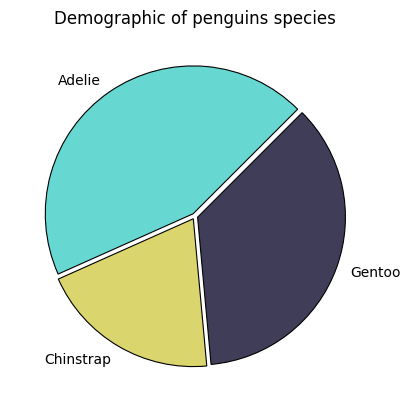

In [13]:
# Visualizing the data (categorical)

species_counter = Counter(df["species"])
labels = list(species_counter.keys())
values = list(species_counter.values())
colors = ["#66D7D1", "#DBD56E", "#403D58"]
explode = [0.02, 0.02, 0.02]

plt.pie(values, 
        labels=labels, 
        colors=colors, 
        startangle=45, 
        explode=explode, 
        wedgeprops={"edgecolor": "black", "linewidth": 0.8})

plt.title("Demographic of penguins species")
plt.show()

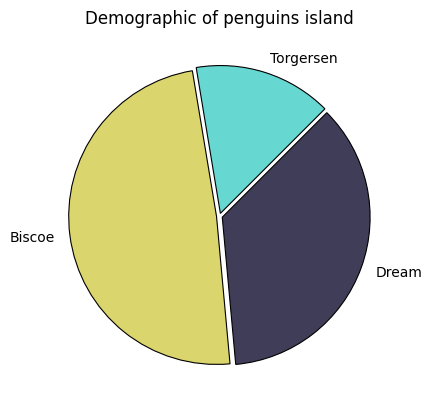

In [14]:
# Visualizing the data (categorical)

island_counter = Counter(df["island"])
labels = list(island_counter.keys())
values = list(island_counter.values())
colors = ["#66D7D1", "#DBD56E", "#403D58"]
explode = [0.02, 0.02, 0.02]

plt.pie(values, 
        labels=labels, 
        colors=colors, 
        startangle=45, 
        explode=explode, 
        wedgeprops={"edgecolor": "black", "linewidth": 0.8})

plt.title("Demographic of penguins island")
plt.show()

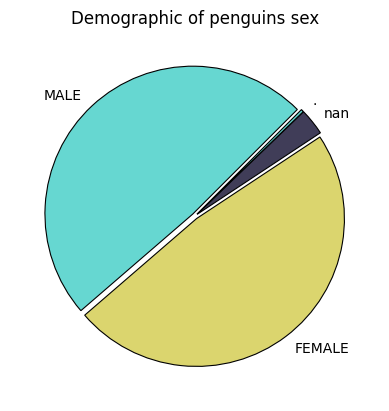

In [15]:
# Visualizing the data (categorical)

sex_counter = Counter(df["sex"])
labels = list(sex_counter.keys())
values = list(sex_counter.values())
colors = ["#66D7D1", "#DBD56E", "#403D58"]
explode = [0.02, 0.02, 0.02, 0.02]

plt.pie(values, 
        labels=labels, 
        colors=colors, 
        startangle=45, 
        explode=explode, 
        wedgeprops={"edgecolor": "black", "linewidth": 0.8})

plt.title("Demographic of penguins sex")
plt.show()

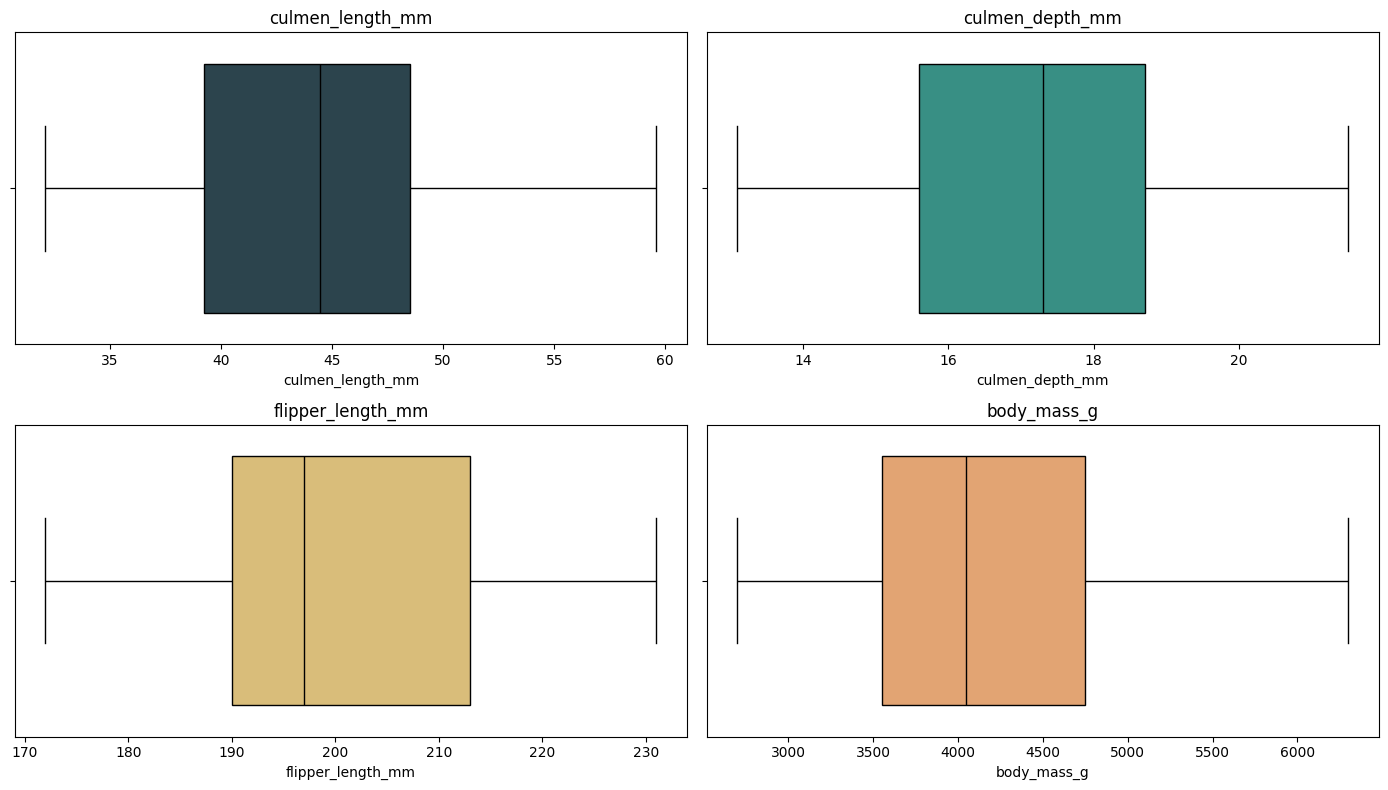

In [16]:
# Searching for numeric outliers:
# culmen_length_mm	culmen_depth_mm	flipper_length_mm	body_mass_g

n_cols = len(numerical_col)
n_rows = (n_cols + 1) // 2 

fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_col):
    sns.boxplot(x=df[col].dropna(), ax=axes[i], color=palette_list[i], linecolor="#000000")
    axes[i].set_title(col)

for j in range(n_cols, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [17]:
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower) | (df[col] > upper)]
print(len(outliers))

0


# Checking for correlations

In [18]:

for penguin_species in df['species'].dropna().unique():
    df_species = df[df['species'] == penguin_species].copy()
    print(f'Penguin species:{penguin_species}')
    print(df_species[numerical_col].corr().round(4))
    print('--------------------------------------------')

Penguin species:Adelie
                   culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
culmen_length_mm             1.0000           0.3915             0.3258   
culmen_depth_mm              0.3915           1.0000             0.3076   
flipper_length_mm            0.3258           0.3076             1.0000   
body_mass_g                  0.5489           0.5761             0.4682   

                   body_mass_g  
culmen_length_mm        0.5489  
culmen_depth_mm         0.5761  
flipper_length_mm       0.4682  
body_mass_g             1.0000  
--------------------------------------------
Penguin species:Chinstrap
                   culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
culmen_length_mm             1.0000           0.6535             0.4716   
culmen_depth_mm              0.6535           1.0000             0.5801   
flipper_length_mm            0.4716           0.5801             1.0000   
body_mass_g                  0.5136           0.6045             

In [19]:
df.groupby("species")[
    ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
].mean()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.791391,18.346358,189.953642,3700.662252
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.504878,14.982114,217.186992,5076.016260


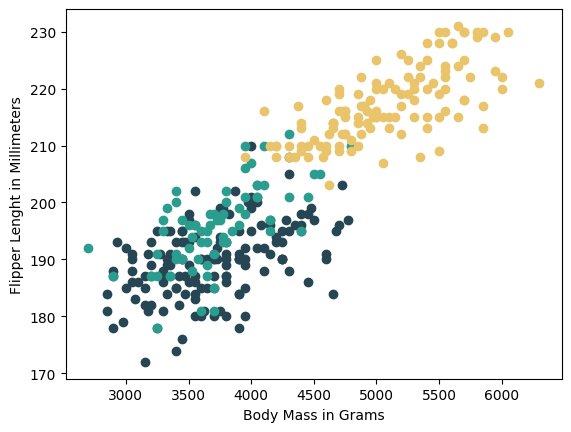

In [28]:
# Ploting a chart that displays penguins "size" grouping by penguins species

# X
colors = ["#47A025", "#6B0504", "#D5E68D"]

for i, specie in enumerate(df["species"].unique().tolist()):
    x = df[df["species"] == specie]["body_mass_g"].tolist()
    y = df[df["species"] == specie]["flipper_length_mm"].tolist()
    plt.scatter(x, y, color=palette_list[i])

plt.xlabel("Body Mass in Grams")
plt.ylabel("Flipper Lenght in Millimeters")
plt.show()

C:\Users\leona\AppData\Local\Temp\ipykernel_21880\1980737957.py:8: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(


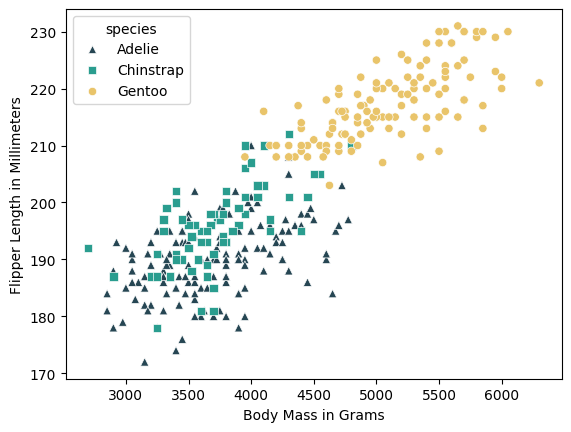

In [36]:
# Ploting a chart that displays penguins "size" grouping by penguins species
markers = {
    "Adelie": "^",
    "Chinstrap": "s",
    "Gentoo": "o"
}

sns.scatterplot(
    data=df,
    x="body_mass_g",
    y="flipper_length_mm",
    hue="species",
    style="species",
    markers=markers,
    palette=palette_list
)

plt.xlabel("Body Mass in Grams")
plt.ylabel("Flipper Length in Millimeters")
plt.show()

In [21]:
#### INSIGHTS

### ! Islands and Species
# Adelie penguins habits all three islands, but they are exclusive in torgersen island
# Biscoe Island is the main island for the Gentoo. Dream is the main island for the Chinstrap
# And Torgersen is the main island for the Adelie (Adelie is also the only species that appear in all 3 islands)
# Biscoe = Gentoo || Dream = Chinstrap || Torgersen = Adelie

### ! Numerical values
# No possible outliers
## ? Gentoo
# Gentoo are massive in weight, having the biggest body mass. (137% of the mass of the other species)
# Gentoo have more sharp culmen and bigger flippers
## ? Adelie
# Adelie penguins have less weight and smaller flippers
# Their culmen are the smallest among them all but their depht are a little bit above average
## ? Chinstrap
# Chinstrap are almost equal to the adelie species, but they have a bigger culmen (even bigger than the gentoo's ones)
# They also have a slighty bigger flipper comparing with the adelies, and a culmen of (aprox.) the same size
